In [1]:
# Import required packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from astropy import units as u, constants as c
from astropy.io import fits
from astropy.time import Time
from astropy.coordinates import EarthLocation, SkyCoord
from astropy.modeling import models, fitting

from scipy.signal import medfilt, argrelmin
from scipy.interpolate import splev, splrep

from specreduce.tracing import FlatTrace
from specreduce.extract import BoxcarExtract

import warnings
import GISIC

In this notebook, we show how to derive robust radial velocities (RVs) from Next Generation Palomar Spectrograph (NGPS) 2D spectra produced by the QuickLook Data Release Pipeline. We will use an 0.5'' slit observation of Gaia-ESO RV Standard GES J17443177+0518564, which has a known RV of 11.05 km/s, as an example. We expect the precision on our derived RVs to be 5 km/s (see Nagarajan & El-Badry, forthcoming).

# Extraction of 1D Spectra

NGPS has three chips, and we expect the trace of the target to be near the center of the central chip. We will manually extract the 1D spectrum using a boxcar window centered on the spatial location of this trace. Note that the GUI of the NGPS QuickLook DRP can also be used for spectral extraction. At the present time, there is no functionality to estimate flux errors.

In [2]:
def find_trace_pixel(slice, search_width = 30):
    '''
    Finds the pixel (in the spatial direction) associated with the trace.
    Parameters:
        slice: 1D array, spatial slice of 2D spectrum
        search_width: float, half-width of search window (in pixels) centered on center of slice
    Returns:
        pixel of trace as a float
    '''
    y_expected = len(slice) // 2 

    y_min = max(0, y_expected - search_width)
    y_max = min(len(slice), y_expected + search_width)

    window = slice[y_min:y_max]
    return y_min + np.nanargmax(window)    

def extract_1D_spec(file):
    '''
    Extracts 1D spectrum from 2D spectrum. Assumes that the trace position is fixed along the spatial axis.
    Parameters:
        file: path pointing to 2D spectrum
    Returns:
        1D spectrum (wavelength solution in Angstroms and observed flux in arbitrary units)
    '''
    ngps_fits = fits.open(file)
    ngps_primary = ngps_fits[0].data
    ngps_data = ngps_fits[1].data
    ngps_sky_model = ngps_fits[2].data
    ngps_wave_sol = ngps_fits[3].data
    ngps_fits.close()

    # Sky subtraction
    sky_sub = ngps_data - ngps_sky_model
    trace_idx = find_trace_pixel(sky_sub[:, 200])
    wavesol = ngps_wave_sol[200]

    # Trace extraction
    trace = FlatTrace(sky_sub, trace_idx)
    extract = BoxcarExtract(sky_sub, trace, width = 4)
    ext_flux = extract.spectrum.flux
    return wavesol, ext_flux

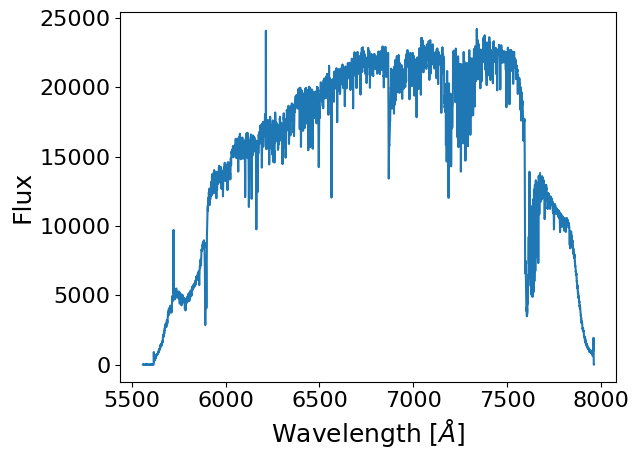

In [3]:
# r filter example
ex_wavl, ex_flux = extract_1D_spec('spec2d_ngps_250721_0056_R.fits')

plt.xlabel(r'Wavelength [$\AA$]', size = 18)
plt.ylabel(r'Flux', size = 18)
plt.tick_params(labelsize = 16, which = 'both')
plt.plot(ex_wavl, ex_flux);

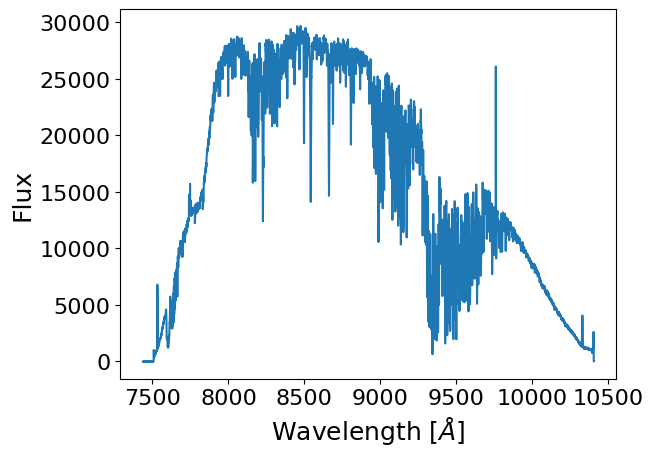

In [4]:
# i filter example
ex_wavl, ex_flux = extract_1D_spec('spec2d_ngps_250721_0056_I.fits')

plt.xlabel(r'Wavelength [$\AA$]', size = 18)
plt.ylabel(r'Flux', size = 18)
plt.tick_params(labelsize = 16, which = 'both')
plt.plot(ex_wavl, ex_flux);

# Flexure Correction with Telluric Absorption Lines

To account for shifts in the wavelength solution, or "flexure," we will compare the observed wavelengths of molecular oxygen absorption bands against the expected wavelengths from a telluric model from the HITRAN2020 database. In detail, we use the Fraunhofer B and A bands to calculate flexure corrections in the r and i channels, respectively. For an explanation on how to generate a grid of telluric models for a given spectral resolution, see Nagarajan et al. (2023) and the associated Github [here](https://github.com/pranav-nagarajan/DBSP-Flexure-Corrections). 

In [5]:
# R = 4000 telluric absorption model spectra (in vacuum) generated for a grid of airmasses at Palomar Observatory.
tmp = np.load('telluric_grid_airmass_r4000.npz')
wl_ref = tmp['wl_grid']
airmass_vals = tmp['airmass_vals']
telluric_grids = tmp['telluric_grids']
tmp.close()

The NGPS spectra are in air wavelengths, so we need a utility function to convert to vacuum wavelengths when necessary.

In [6]:
def convert_air_to_vacuum(wave_air):
    '''
    Only valid above 2000 Angstroms.
    '''
    wave_vac = np.copy(wave_air)
    for i in [0, 1]:
        sigma2 = (1e4 / wave_vac) ** 2
        f = 1.0 + 0.05792105 / (238.0185 - sigma2) + 0.00167917 / (57.362 - sigma2)
        wave_vac = wave_air * f
    return wave_vac

We also need a utility function to apply a Doppler shift to a spectrum.

In [7]:
def doppler_shift(wavelength, flux, dv):
    '''
    Utility function for applying a Doppler shift to a spectrum.
    Parameters:
        wavelength: 1D array, wavelength solution in Angstroms
        flux: 1D array, flux in arbitrary units
        dv: float, Doppler shift in km/s
    Returns:
        Doppler-shifted flux interpolated onto the supplied wavelength grid
    '''
    c = 299792.458
    doppler_factor = np.sqrt((1 - dv/c)/(1 + dv/c))
    new_wavelength = wavelength * doppler_factor
    long_wl = np.concatenate([[np.min(wavelength) - 1], wavelength, [np.max(wavelength) + 1]])
    long_flux = np.concatenate([[1], flux, [1]])
    spl = splrep(long_wl, long_flux)
    new_flux = splev(new_wavelength, spl)
    return new_flux

Now we have all the tools to compute the flexure correction for a given spectral region. The airmass of the observation can be retrieved from the header of the corresponding FITS file.

In [8]:
def flexure_correction(wl, flux, this_airmass, flex_range = 100, wl_min = 7585, wl_max = 7650, plot = True):
    '''
    Code to calculate a flexure correction for a 1D spectrum based on telluric absorption features.
    Parameters:
        wl: 1D array, vacuum wavelengths of observed spectrum in Angstroms
        flux: 1D array, observed flux in arbitrary units
        this_airmass: float, airmass of observation
        flex_range: float, half-width of RV grid in km/s
        wl_min, wl_max: float, bounds of window defining spectral region to fit to telluric model spectrum
    Returns:
        flexure correction in km/s
    '''

    # Normalize the observed spectrum
    wl, norm_flux, continuum = GISIC.normalize(wl, flux.value, sigma = 100, s = 7)

    # Placeholder for flux error
    norm_err = np.ones(len(norm_flux)) * 0.1
    norm_err[norm_flux > 2] = np.inf

    # Retrieve telluric model spectrum
    ai = min(int(np.round((this_airmass-airmass_vals[0])/(airmass_vals[1]-airmass_vals[0]))), len(airmass_vals)-1)
    flux_ref = telluric_grids[ai]

    # Fit only in the specified spectral region
    m_ref = (wl_ref > wl_min) & (wl_ref < wl_max)
    tell_msk = (wl > wl_min) & (wl < wl_max)

    # Search for the best-fit flexure correction
    dvs = np.arange(-flex_range, flex_range, 0.1)
    chi2s = []
    for dv in dvs:
        flam_shift = doppler_shift(wl_ref[m_ref], flux_ref[m_ref], dv)
        this_interp = np.interp(wl[tell_msk], wl_ref[m_ref], flam_shift)
        this_chi = (this_interp - norm_flux[tell_msk]) ** 2 / norm_err[tell_msk] ** 2
        chi2s.append(np.sum(this_chi))
    chi2s = np.array(chi2s)
    best_shift = dvs[np.argmin(chi2s)] 
    
    if plot:
        f, ax = plt.subplots(1, 2, figsize = (20, 6))
        ax[0].plot(wl, norm_flux, 'k', label = 'Observed')
        ax[0].plot(wl_ref, flux_ref, 'r', label = 'Original Template')
        ax[0].plot(wl_ref, doppler_shift(wl_ref, flux_ref, best_shift), 'c', label = 'Shifted Template')
        ax[0].set_xlim(wl_min, wl_max)
        ax[0].set_ylim(0, 1.5)
        ax[0].set_xlabel('Wavelength (Angstroms)', size = 16)
        ax[0].set_ylabel('Flux', size = 16)
        ax[0].legend(fontsize = 14, loc = 'upper right')
        ax[0].tick_params(labelsize = 14, which = 'both')
        ax[1].plot(dvs, chi2s - np.min(chi2s))
        ax[1].set_xlabel('Radial Velocity Shift (km/s)', size = 16)
        ax[1].set_ylabel(r'$\chi^2 - \chi^2_{\min}$', size = 16)
        ax[1].tick_params(labelsize = 14, which = 'both')
    return best_shift


def flexcorr_pipeline(file, wl_min = 7585, wl_max = 7650, plot = True):
    '''
    Pipeline for calculating NGPS flexure corrections.
    Parameters:
        file: path to 2D NGPS spectrum from QuickLook DRP
        wl_min, wl_max: float, bounds of window defining spectral region to fit to telluric model spectrum
        cont_min, cont_max: float, bounds of window defining continuum for normalization 
    Returns:
        flexure correction in km/s
    '''
    hdul = fits.open(file)
    airmass = hdul[0].header['AIRMASS']
    hdul.close()
    wavesol, flux = extract_1D_spec(file)
    wavesol = convert_air_to_vacuum(wavesol)
    best_shift = flexure_correction(wavesol, flux, airmass, wl_min = wl_min, wl_max = wl_max, plot = plot)
    return best_shift

28.59999999999269

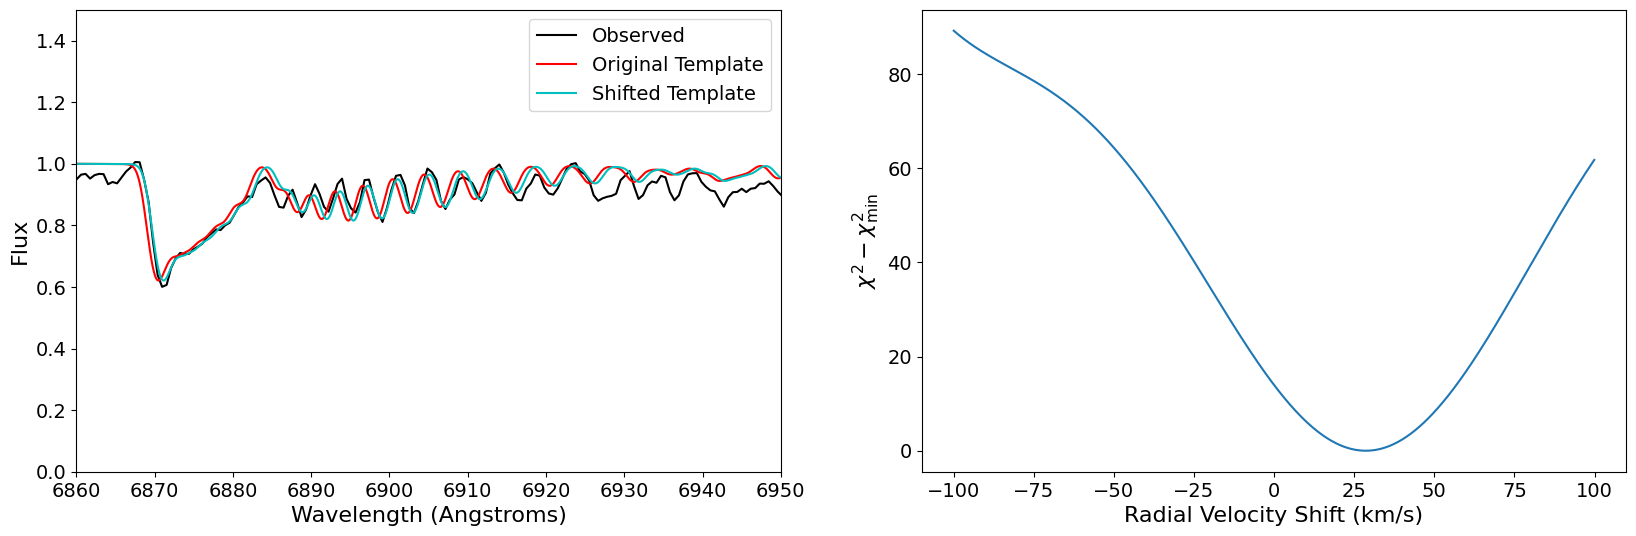

In [9]:
# Telluric B-band of oxygen
flexcorr_pipeline('spec2d_ngps_250721_0056_R.fits', wl_min = 6860, wl_max = 6950)

-60.30000000000226

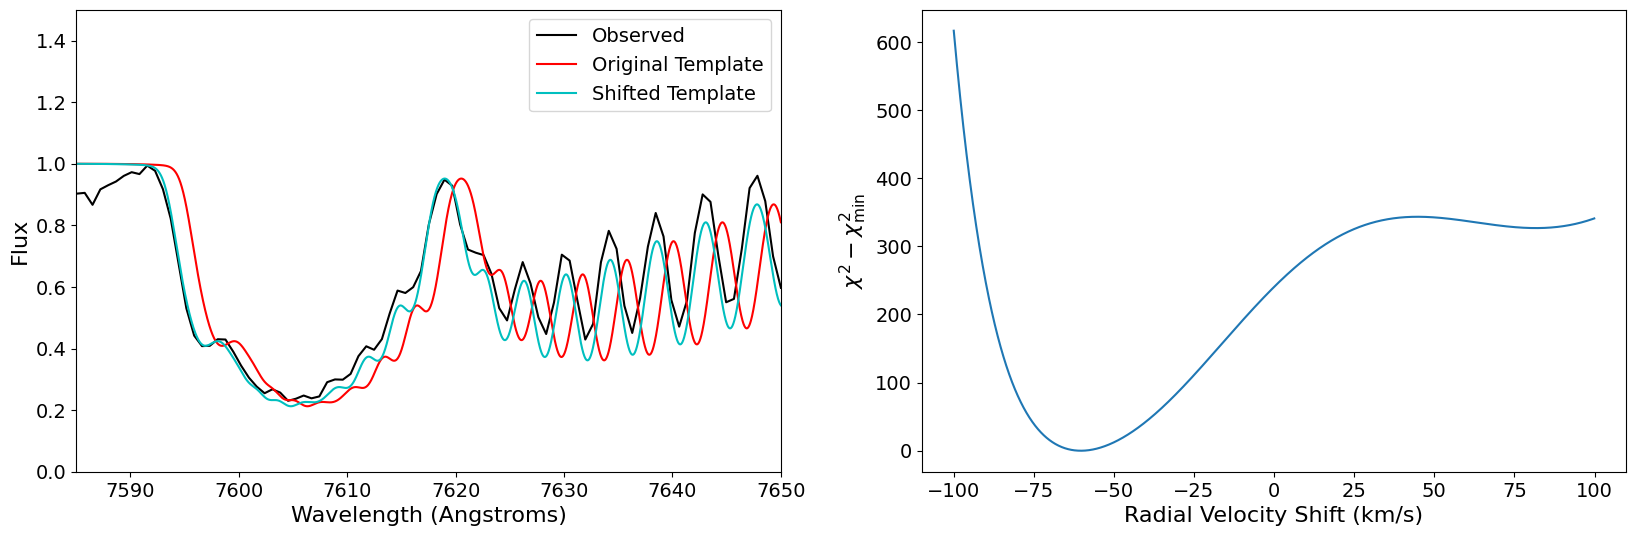

In [10]:
# Telluric A-band of oxygen
flexcorr_pipeline('spec2d_ngps_250721_0056_I.fits', wl_min = 7585, wl_max = 7650)

# Radial Velocities

The GAIA-ESO survey estimates spectroscopic parameters for radial velocity standards. For our target, we retrieve the appropriate BOSZ Kurucz template stellar spectrum from [this website](https://archive.stsci.edu/hlsp/bosz). The template spectra are in air wavelengths.

In [11]:
# BOSZ Kurucz R = 5000 template spectrum
# T_eff = 4750 K, log g = 4.5, solar metallicity
bosz_wavls = np.genfromtxt('bosz2024_wave_r5000.txt')
bosz_spec = np.genfromtxt('bosz2024_mp_t4750_g+4.5_m+0.00_a+0.00_c+0.00_v2_r5000_resam.txt.gz')
bosz_flux = bosz_spec[:, 0] / bosz_spec[:, 1]

The NGPS QuickLook DRP does not derive barycenter corrections, so we should do that ourselves.

In [12]:
def convert_to_hjd(mjd_utc, ra, dec, site = 'Palomar'):
    '''
    Convert from local time to HJD (all UTC).
    Parameters:
        mjd_utc (float): MJD of observation
        ra, dec (float): RA and Dec of target in degrees
        site (str): Observation site
    Returns:
        HJD of observation
    '''
    jd_utc = mjd_utc + 2400000.5
    
    loc = EarthLocation.of_site(site)
    time_inp = Time(jd_utc, format='jd', scale='utc', location=loc)

    target = SkyCoord(ra, dec, unit=(u.deg, u.deg), frame='icrs')
    ltt_helio = time_inp.light_travel_time(target, 'heliocentric')
    hjd_utc = jd_utc + ltt_helio.to(u.day).value
    
    return hjd_utc


def barycenter_correction(ra, dec, jd, site = 'Palomar'):
    '''
    Compute barycenter correction in km/s.
    Parameters:
        ra, dec (float): RA and Dec of target in degrees
        jd (float): JD of observation (UTC)
        site (str): Observation site
    Returns:
        barycenter correction in km/s
    '''
    coordinate = SkyCoord(ra = ra * u.deg, dec = dec * u.deg, frame = 'icrs')
    obs_time = Time(jd, format = 'jd')
    earth_location = EarthLocation.of_site(site)
    barycorr = coordinate.radial_velocity_correction(obstime = obs_time, location = earth_location)
    return barycorr.to(u.km / u.s).value

The following utility function uses a median filter to normalize the observed target spectrum.

In [13]:
def medfilt_fixed_window_AA(wl, flam, window_AA = 301):
    '''
    Continuum estimation with a median filter.
    Parameters:
        wl: wavelength solution in Angstroms
        flam: flux in arbitrary units
        window_AA: median filter window in Angstroms
    Returns:
        estimate of continuum
    '''
    wl_grid = np.arange(np.min(wl), np.max(wl), 1)
    flam_interp = np.interp(wl_grid, wl, flam)
    cont_interp = medfilt(flam_interp, window_AA)
    cont = np.interp(wl, wl_grid, cont_interp)
    return cont

We now have all of the tools we need to compute radial velocities.

In [14]:
def find_deepest_local_min(arr):
    '''
    Utility function to find deepest local minimum.
    '''
    idxs = argrelmin(arr)[0]
    min_vals = [arr[idx] for idx in idxs]
    deepest = np.argmin(min_vals)
    return idxs[deepest]
    

def overlay_spectra(obs_wavl, obs_flux, temp_wavl, temp_flux, rv, save = False, lims = None):
    '''
    Helper function to plot observed and template spectra.
    '''
    if lims is None:
        low_lim, high_lim = np.min(obs_wavl), np.max(obs_wavl)
    else:
        low_lim, high_lim = lims
    continuum = medfilt_fixed_window_AA(obs_wavl, obs_flux, window_AA = 21)
    norm_flux = np.divide(obs_flux, continuum, out = np.zeros_like(obs_flux, dtype = float), 
                          where = continuum != 0)

    temp_mask = (temp_wavl > np.min(obs_wavl)) & (temp_wavl < np.max(obs_wavl))
    new_temp_flux = doppler_shift(temp_wavl[temp_mask], temp_flux[temp_mask], rv)

    ovfig = plt.figure(figsize = (15, 5))
    plt.plot(obs_wavl, norm_flux, color = 'orange', label = 'Observation')
    plt.plot(temp_wavl[temp_mask], new_temp_flux, color = 'blue', label = 'Template')
    plt.xlabel(r'Observed Wavelength [$\AA$]', fontsize = 18)
    plt.ylabel('Normalized Flux', fontsize = 18)
    plt.tick_params(pad = 10, labelsize = 18, which = 'both')
    plt.xlim(low_lim, high_lim)
    plt.ylim(0.4, 1.2)
    plt.legend(fontsize = 18)
    plt.show();
    return ovfig
    

def radial_velocity(obs_wavl, obs_flux, temp_wavl, temp_flux, flex_corr = 0, bary_corr = 0,
                    plot = True, overlay = True, lims = None):
    '''
    Function to compute radial velocities via comparison to a template spectrum.
    Parameters:
        obs_wavl (arr): Observed wavelengths in Angstroms
        obs_flux (arr): Observed flux in arbitrary units
        temp_wavl (arr): Template wavelengths in Angstroms
        temp_flux (arr): Template flux in arbitrary units, normalized
        flex_corr (float): Flexure correction in km/s
        bary_corr (float): Barycenter correction in km/s
    Returns:
        Measured RV and RV error        
    '''

    # Normalize the observed spectrum
    continuum = medfilt_fixed_window_AA(obs_wavl, obs_flux, window_AA = 21)
    norm_flux = obs_flux / continuum

    # Placeholder for flux errors
    normfluxerr = np.ones(len(norm_flux)) * 0.1
    normfluxerr[norm_flux > 2] = np.inf
    normfluxerr[(obs_wavl < (np.min(obs_wavl) + 10)) | (obs_wavl > (np.max(obs_wavl) - 10))] = np.inf

    # Fit only the specified spectral region
    wl_min, wl_max = np.min(obs_wavl), np.max(obs_wavl)
    if lims is not None:
        wl_min, wl_max = lims[0], lims[1]
    temp_mask = (temp_wavl > wl_min) & (temp_wavl < wl_max)

    # Search for the best-fit RV
    shifts = np.arange(-400, 400, 0.3)
    chi2s = []
    for shift in shifts:
        shifted_template = doppler_shift(temp_wavl[temp_mask], temp_flux[temp_mask], shift)
        normalized_template = np.interp(obs_wavl, temp_wavl[temp_mask], shifted_template)
        chi2 = (normalized_template - norm_flux) ** 2 / normfluxerr ** 2
        m = (obs_wavl > wl_min) & (obs_wavl < wl_max) & (norm_flux < 2.0)
        chi2s.append(np.nansum(chi2[m]))
    chi2s = np.array(chi2s)
    best_rv = shifts[find_deepest_local_min(chi2s)]

    # Repeat on a finer grid
    fine_shifts = np.arange(best_rv - 5, best_rv + 5, 0.03)
    fine_chi2s = []
    for shift in fine_shifts:
        shifted_template = doppler_shift(temp_wavl[temp_mask], temp_flux[temp_mask], shift)
        normalized_template = np.interp(obs_wavl, temp_wavl[temp_mask], shifted_template)
        chi2 = (normalized_template - norm_flux) ** 2 / normfluxerr ** 2
        m = (obs_wavl > wl_min) & (obs_wavl < wl_max) & (norm_flux < 2.0)
        fine_chi2s.append(np.nansum(chi2[m]))
    fine_chi2s = np.array(fine_chi2s)
    best_rv = fine_shifts[np.argmin(fine_chi2s)]

    # Estimate RV error based on chi-squared statistic
    off_by_one = np.argsort(np.abs(fine_chi2s - np.min(fine_chi2s) - 1))
    rv_err_bounds = fine_shifts[off_by_one[0]], fine_shifts[off_by_one[1]]
    rv_err = np.average(np.abs(rv_err_bounds - best_rv))

    # Apply flexure and barycenter corrections
    real_rv = best_rv - flex_corr + bary_corr
    
    if plot:
        chi_fig = plt.figure(figsize = (15, 5))
        plt.plot(shifts, chi2s - np.min(chi2s))
        plt.xlabel(r'Radial Velocity [km s$^{-1}$]', fontsize = 18)
        plt.ylabel(r'$\chi^2 - \chi^2_{\min}$', fontsize = 18)
        plt.xlim(np.min(shifts), np.max(shifts))
        plt.tick_params(labelsize = 18, which = 'both')
        plt.show();

        zoom_fig = plt.figure(figsize = (15, 5))
        plt.plot(fine_shifts, fine_chi2s - np.min(fine_chi2s))
        plt.xlabel('Radial Velocity (km/s)', fontsize = 18)
        plt.ylabel('Chi-Squared', fontsize = 18)
        plt.tick_params(labelsize = 18, which = 'both')
        plt.show();

    if overlay:
        _ = overlay_spectra(obs_wavl, obs_flux, temp_wavl, temp_flux, best_rv, lims = lims)
    return real_rv, rv_err

In [15]:
def rv_pipeline(spec_2D, temp_wavl, temp_flux, plot = False, lims = None):
    '''
    Pipeline to compute RV from a 2D spectrum produced by the NGPS QuickLook DRP.
    Parameters:
        spec_2D (str): path to 2D spectrum
        temp_wavl (arr): Template wavelengths in Angstroms
        temp_flux (arr): Template flux in arbitrary units, normalized
    Returns:
        HJD of observation, measured RV, RV error
    '''

    # Read in required parameters from header
    with fits.open(spec_2D) as hdul:
        header = hdul[0].header
        ra, dec = header['RA'], header['DECL']
        coord = SkyCoord(ra = ra, dec = dec, unit = (u.hourangle, u.deg), frame = 'icrs')
        ra_deg, dec_deg = coord.ra.degree, coord.dec.degree
        jd = Time(header['DATE']).jd
        mjd = jd - 2400000.5
        channel = header['CHANNEL'].strip()

    # 1D spectrum extraction
    obs_wavl, obs_flux = extract_1D_spec(spec_2D)
    obs_flux = obs_flux.value

    # Compute barycenter correction, flexure correction, and best-fit RV
    with warnings.catch_warnings():
        hjd = convert_to_hjd(jd - 2400000.5, ra_deg, dec_deg)
        bary_corr = barycenter_correction(ra_deg, dec_deg, jd)
        warnings.simplefilter("ignore")
        if channel == 'R':
            flex_corr = flexcorr_pipeline(spec_2D, wl_min = 6860, wl_max = 6950, plot = plot)
        else:
            flex_corr = flexcorr_pipeline(spec_2D, wl_min = 7585, wl_max = 7650, plot = plot)
        obs_bool = np.full(np.shape(obs_wavl), True)
        if lims is not None:
            obs_bool = (obs_wavl > lims[0]) & (obs_wavl < lims[1])
        rv_result = radial_velocity(obs_wavl[obs_bool], obs_flux[obs_bool], temp_wavl, temp_flux, 
                                    flex_corr = flex_corr, bary_corr = bary_corr, 
                                    plot = plot, overlay = plot, lims = lims)
        rv, rv_err = rv_result
        
    return hjd, rv, rv_err

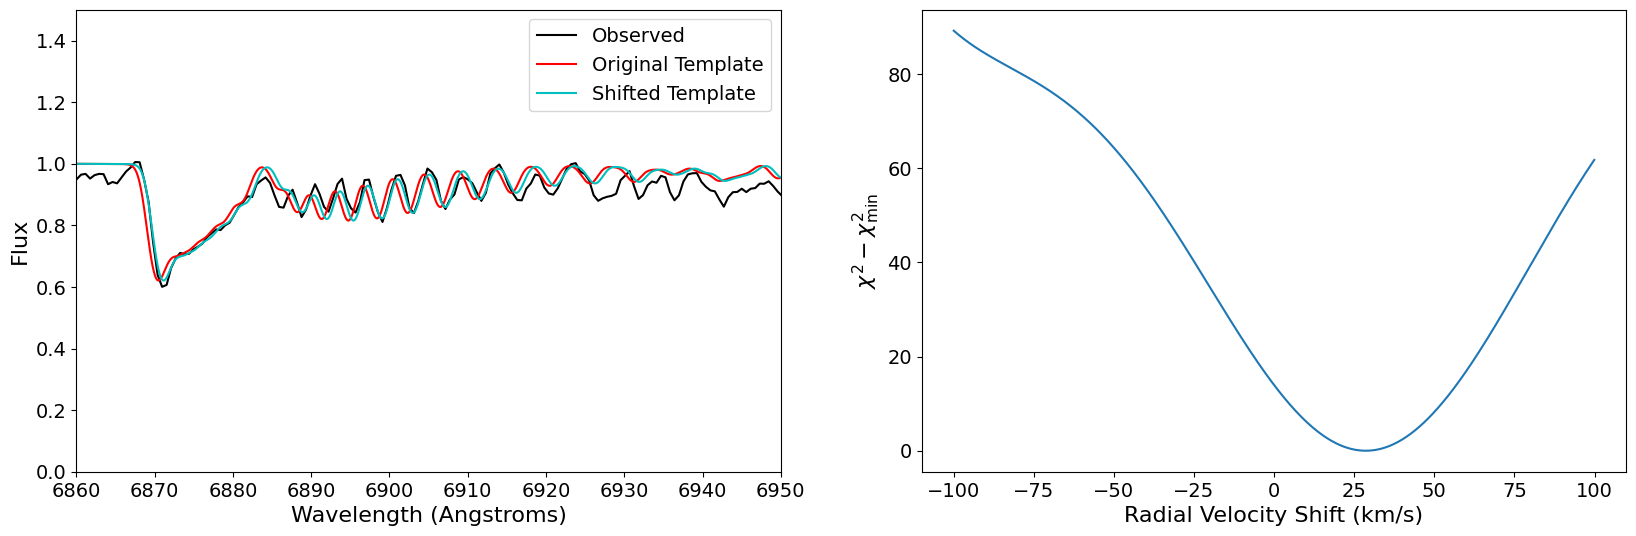

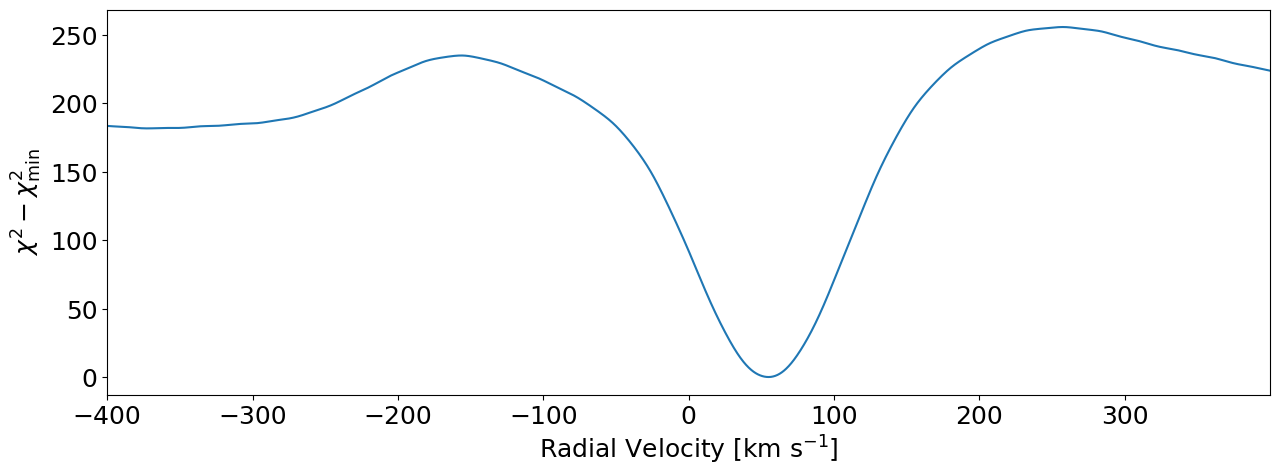

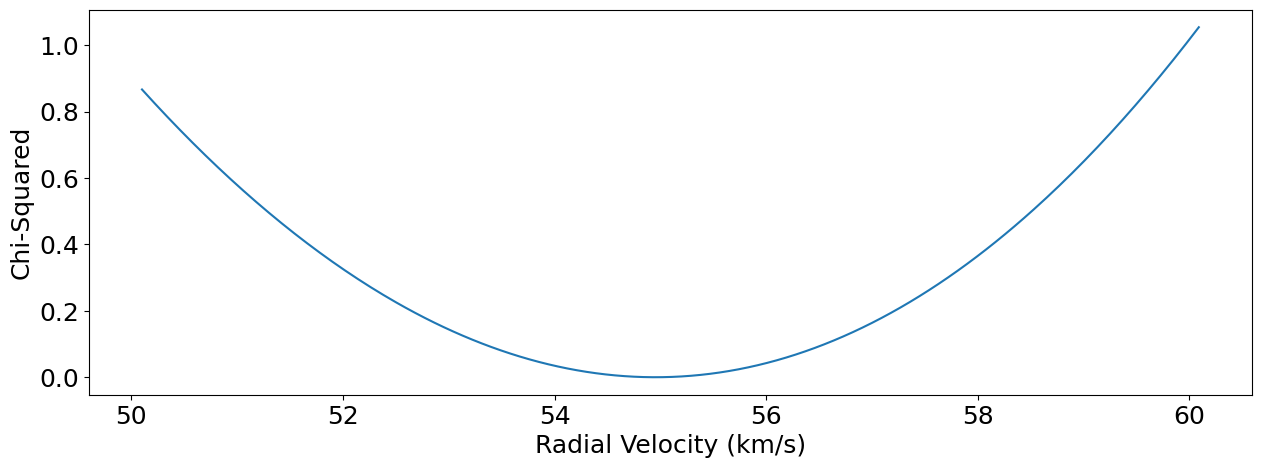

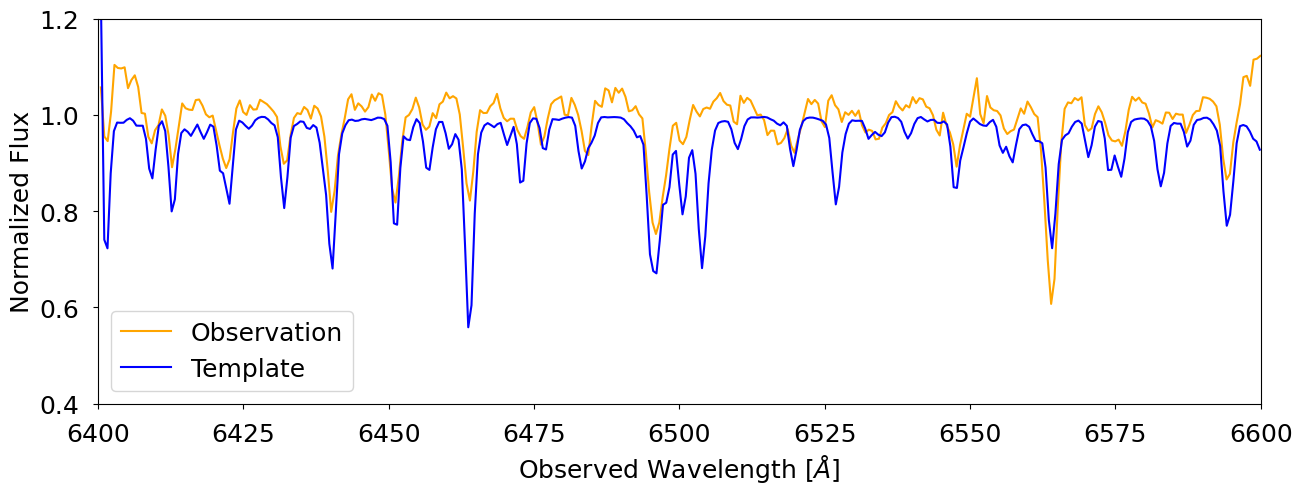

(2460877.769075095, 12.267422853527417, 4.995000000000189)

In [16]:
rv_pipeline('spec2d_ngps_250721_0056_R.fits', bosz_wavls, bosz_flux, lims = (6400, 6600), plot = True)

The best-fit RV of $12 \pm 5$ km/s from the r-band is consistent with the expected value of 11 km/s to within $1\sigma$.

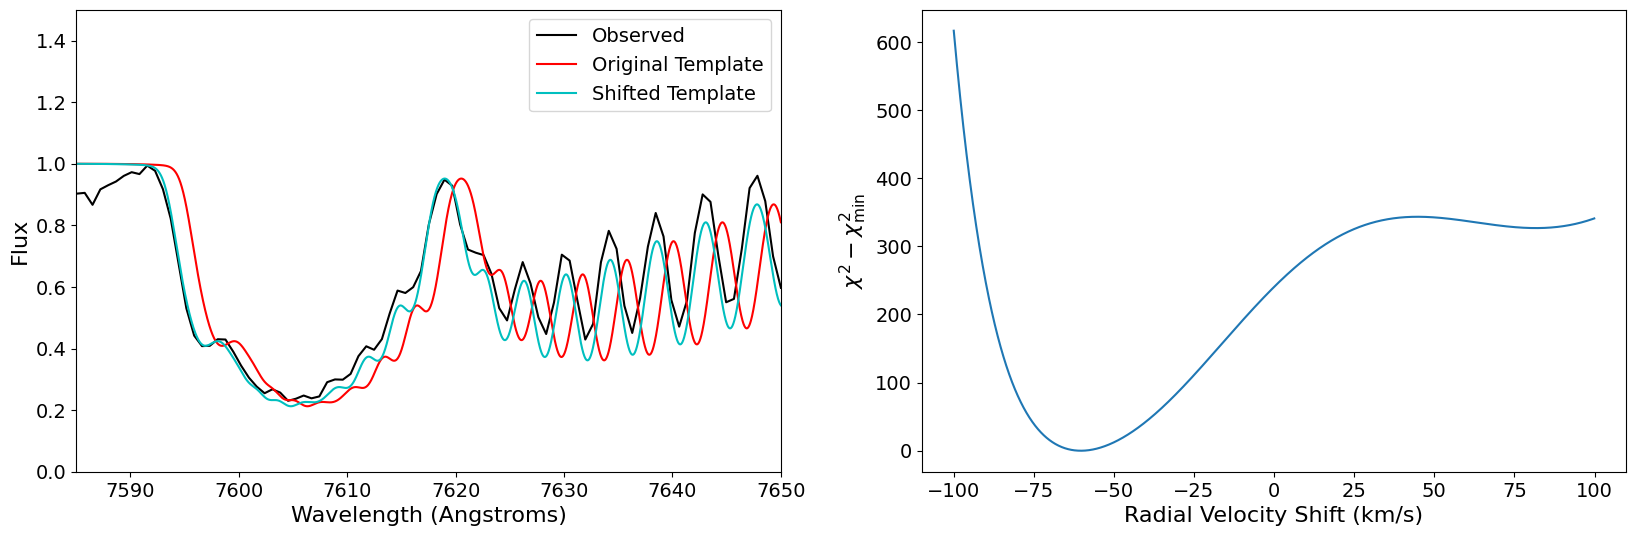

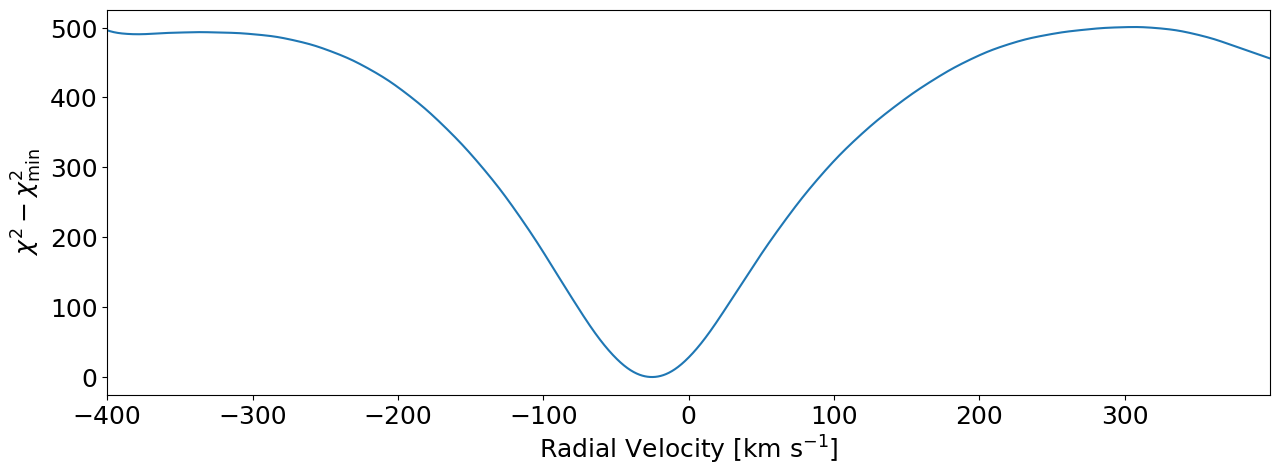

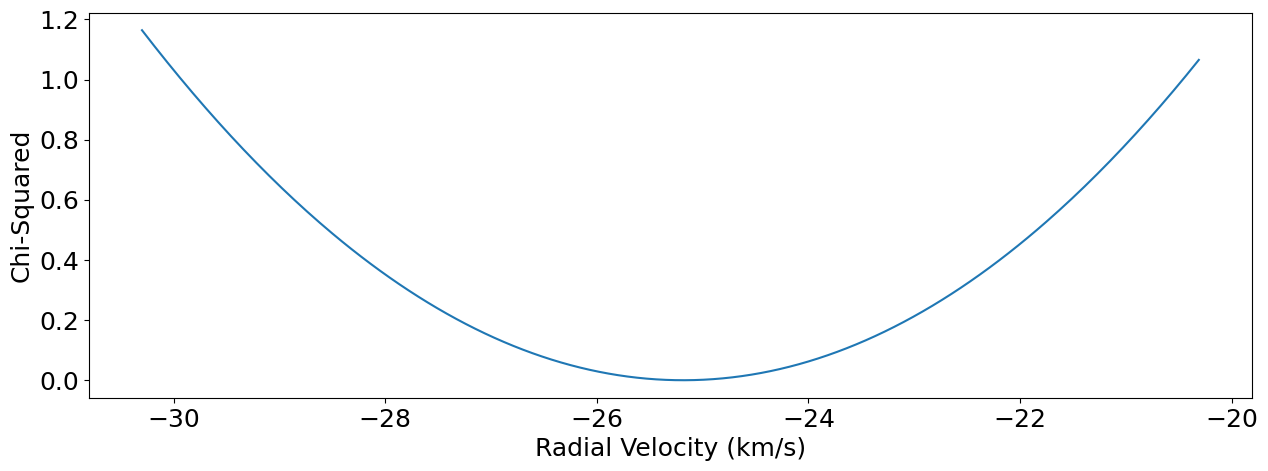

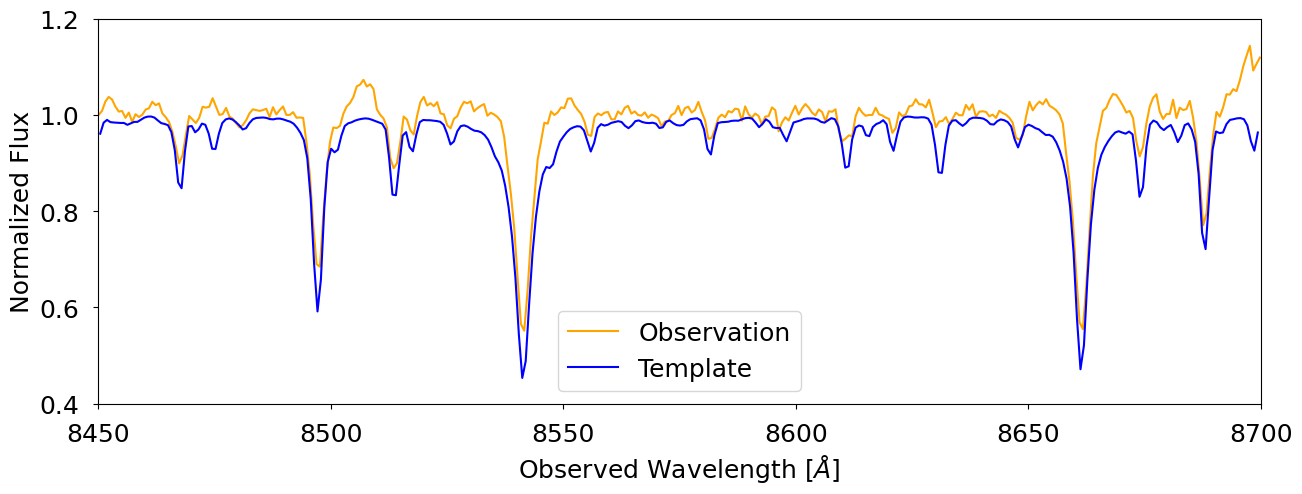

(2460877.769075095, 21.037422853519328, 4.74000000000018)

In [17]:
rv_pipeline('spec2d_ngps_250721_0056_I.fits', bosz_wavls, bosz_flux, lims = (8450, 8700), plot = True)

The best-fit RV of $21 \pm 5$ km/s from the i-band is consistent with the expected value of 11 km/s to within $2\sigma$.

# Conclusion

To maximize accuracy, we recommend using the r-band to compute radial velocities (RVs) in a window around the H-alpha absorption line, with flexure corrections computed using the 688 nm oxygen B-band. From our tests with multiple RV standards (see the figure below), we expect to recover a RV precision of $\sim 5$ km/s with the method described above (Nagarajan & El-Badry, forthcoming).

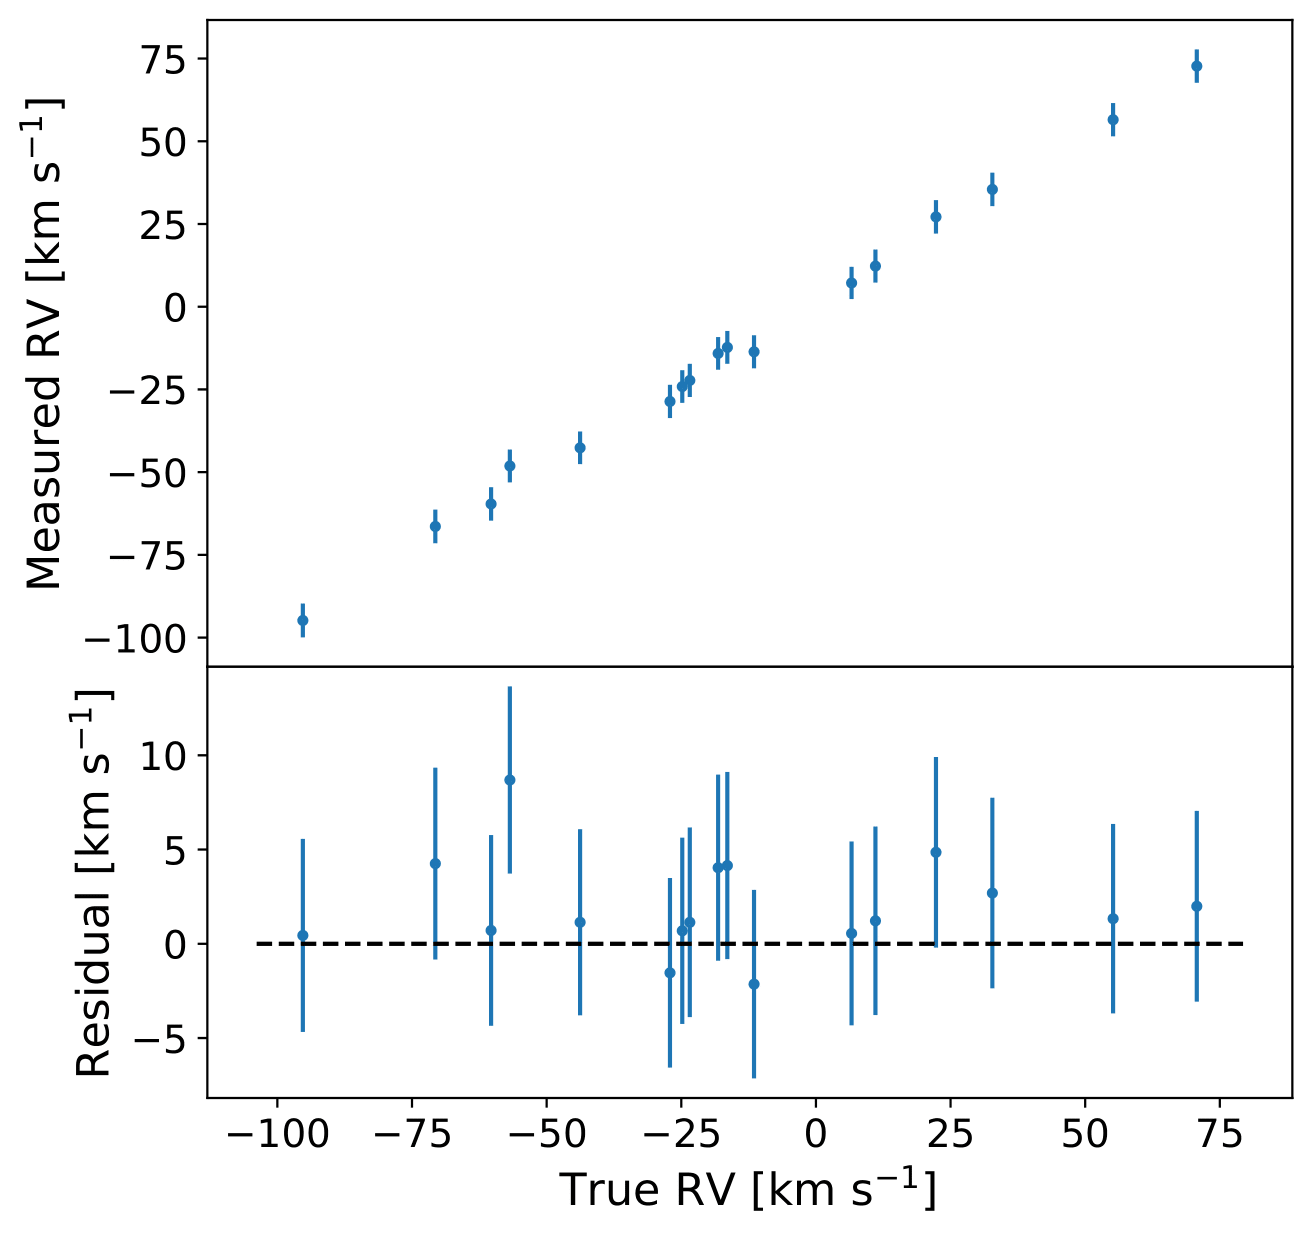

In [18]:
from IPython.display import Image

Image('RV_Comparison_Figure.png')